<h1 style="font-size:300%">ANIMAL SOUND CLASSIFIER</h1>

This notebook is a starting point for a multiclass classification model that predicts to which animal species a sound recording belongs based on features extracted from those recordings. It uses a subset of [YashNita's Animal Sound Dataset](https://github.com/YashNita/Animal-Sound-Dataset), focusing on five specific animal classes: chicken, cow, donkey, frog, and sheep.

Bas S.H.T. Michielsen, 2025

<img src="https://raw.githubusercontent.com/bshtmichielsen/animal_sound_identifier/refs/heads/main/BANNER.jpg" />

*Image by Stable Diffusion: a machine that can classify animal sounds*

In [ ]:
import librosa, os, pandas, platform, torch
from torch import nn
import lightning as L
import torch.utils.data as D
import torchmetrics as M

import os
os.environ["LIGHTNING_TIPS_DISABLE"] = "1"   # or "LIGHTNING_TIPS_DISABLE"

torch.manual_seed(42)

torch.set_float32_matmul_precision('high') # For Cuda Tensor Cores

data_path = "data"
sample_length = 200

print("Versions: python", platform.python_version(), "| torch", torch.__version__, "| lightning", L.__version__, "| librosa", librosa.__version__)

Versions: python 3.14.2 | torch 2.9.1+cu130 | lightning 2.6.0 | librosa 0.11.0


# Create a Dataset

The first thing to do is create a torch Dataset object that can load the provided audio files. A toch DataSet has a `__getitem__` function that should return a tensor of floats, as this is the input that machine learning models accept. Therefore, `librosa` is used to extract values from the audio files. This example demonstrates the extraction of [Mel-frequency Cepstral Coefficients](https://www.geeksforgeeks.org/nlp/mel-frequency-cepstral-coefficients-mfcc-for-speech-recognition/) (MFCC) features, which are often used in speech recognition, but are likely to function reasonably well for animal sounds too. Because the audio files are of different length, and machine learning models by definition work with equal length inputs, the resulting mfcc tensor is either padded with zeros or truncated to the value of `sample_length`. 


In [2]:
class AudioDataset(D.Dataset):
    def __init__(self, path, sample_length):
        self.sample_length = sample_length
        self.files = []
        self.labels = []
        self.classes = os.listdir(path)
        self.n_mfcc = 13
        for label in self.classes:
            class_dir = os.path.join(path, label)
            if os.path.isdir(class_dir):
                for file in os.listdir(class_dir):
                    if file.endswith('.wav'):
                        self.files.append(os.path.join(class_dir, file))
                        self.labels.append(self.classes.index(label))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, index):
        audio_path = self.files[index]
        label = self.labels[index]
        audio, _ = librosa.load(audio_path)
        mfcc = librosa.feature.mfcc(y=audio, n_mfcc=self.n_mfcc)
        mfcc_tensor = torch.tensor(mfcc, dtype=torch.float32)
        if mfcc_tensor.shape[1] < self.sample_length: # Pad with zeros
            padding = (0, self.sample_length - mfcc_tensor.shape[1])
            mfcc_tensor = nn.functional.pad(mfcc_tensor, padding, mode='constant', value=0)
        else: # Truncate
            mfcc_tensor = mfcc_tensor[:, :self.sample_length]
        return mfcc_tensor, label

    def num_classes(self):
        return len(self.classes)
    
    def num_features(self):
        return self.n_mfcc
    
dataset = AudioDataset(data_path, sample_length)
print("Created a DataSet with", len(dataset), "items for the following classes:", dataset.classes)

Created a DataSet with 205 items for the following classes: ['chicken', 'cow', 'donkey', 'frog', 'sheep']


# Sample the data

Looking at the first instance for each of the classes we can observe that the resulting tensors contain quite different information, which should help your classification model to distinguish them.

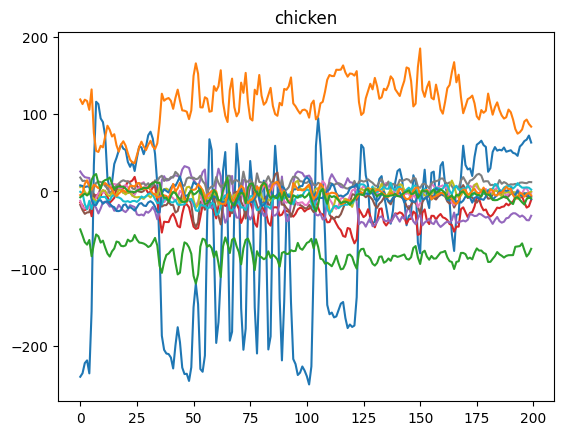

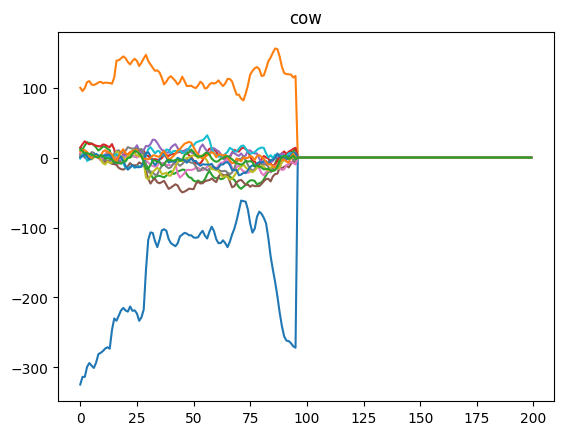

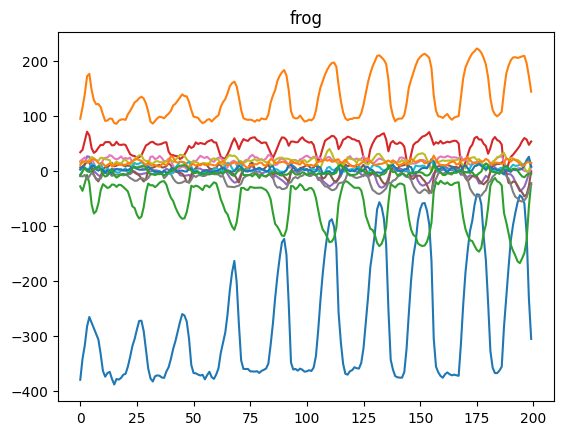

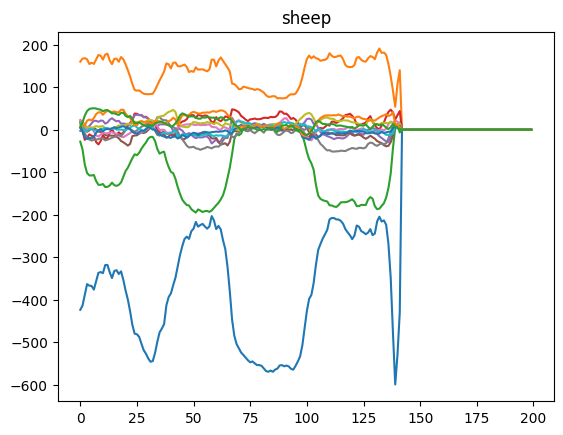

In [3]:
for data in [dataset[0], dataset[45], dataset[150], dataset[200]]:
    plot = pandas.DataFrame(torch.t(data[0])).plot(legend=None, title=dataset.classes[data[1]])

# Splitting the Dataset

For the sake of simplicity, here we randomly split our dataset into 50% train data, 30% validation data and 20% test data. Any other random split could be equally valid based on the use case. 

In [4]:
train, val, test = D.random_split(dataset, [.5, .3, .2])
datamodule = L.LightningDataModule.from_datasets(train, val, test, batch_size=32, num_workers=0)
print("Created a DataModule with:", len(datamodule.train_dataloader().dataset), "training items,", len(datamodule.val_dataloader().dataset), "validation items and", len(datamodule.test_dataloader().dataset), "test items.")

Created a DataModule with: 103 training items, 61 validation items and 41 test items.


# Defining the Model
Here we build a simple 1‑D convolutional neural network for a multi‑class classification task. The first convolution scans the input sequence with 32 filters of length 3, preserving the original length thanks to the padding. The ReLU adds non‑linearity, enabling the network to capture complex patterns. Afterthat Max‑pooling reduces the temporal dimension by a factor of `pool_stride`, providing translation invariance and lowering computational cost. The same pattern then repeats for a second convolution that expands the channel depth to 64, followed by another ReLU and max‑pooling step, further compressing the sequence length. After the convolutions, the result which is a 3‑D tensor (batch × channels × time) in flattened into a 2‑D matrix so it can be fed into fully‑connected layers.
The first dense layer maps the flattened feature map to a 256‑dimensional hidden representation, and a subsequent ReLU introduces additional non‑linearity.  Finally, the output layer produces `num_classes` logits, one for each class. This architecture extracts hierarchical features from the raw sequence with convolutions and pooling, and then uses dense layers to perform the final classification.

In [5]:
class AudioClassifier(L.LightningModule):
    def __init__(self, num_classes, num_features, sample_length):
        super().__init__()
        self.num_classes = num_classes
        pool_stride = 2
        self.model = nn.Sequential(
            nn.Conv1d(num_features, 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=pool_stride),
            nn.Conv1d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2, stride=pool_stride),
            nn.Flatten(),
            nn.Linear(64 * (sample_length // pool_stride // pool_stride), 256),
            nn.ReLU(),
            nn.Linear(256, num_classes)
        )
        self.criterion = nn.CrossEntropyLoss()
        self.accuracy = M.Accuracy(task="multiclass", num_classes=num_classes, average="none")
        self.precision = M.Precision(task="multiclass", num_classes=num_classes, average="none")
        self.recall = M.Recall(task="multiclass", num_classes=num_classes, average="none")

    def forward(self, x):
        return self.model(x)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=0.001)

    def training_step(self, batch):
        x, y = batch
        logits = self(x)
        return self.criterion(logits, y)
    
    def validation_step(self, batch):
        x, y = batch
        logits = self(x)
        self.log("val_loss", self.criterion(logits, y))
    
    def test_step(self, batch):
        x, y = batch
        logits = self(x)
        preds = logits.argmax(dim=1)
        self.accuracy(preds, y)
        self.precision(preds, y)
        self.recall(preds, y)

    def on_test_epoch_end(self):
        accuracy = self.accuracy.compute()
        precision = self.precision.compute()
        recall = self.recall.compute()
        for i in range(self.num_classes):
            self.log("test_accuracy_class_" + str(i), accuracy[i])
            self.log("test_precision_class_" + str(i), precision[i])
            self.log("test_recall_class_" + str(i), recall[i])
    
    def predict_step(self, batch):
        x, y = batch
        logits = self(x)
        return logits

model = AudioClassifier(dataset.num_classes(), dataset.num_features(), sample_length)

# Train

Now, let's use the PyTorch Lightning Trainer to train the model with our Data Module. Rather than telling it beforehand how many epochs to train, we use an EarlyStopping callback that stops the training process when the model has reached convergence. Information is logged to a CSV logger that can be used after training to provide evaluation metrics.

In [6]:
from lightning.pytorch.loggers import CSVLogger
from lightning.pytorch.callbacks import EarlyStopping

logger = CSVLogger(save_dir=".")
stop = EarlyStopping(monitor="val_loss", mode="min", patience=5)
trainer = L.Trainer(logger=logger, max_epochs=-1, callbacks=[stop], log_every_n_steps=4)
trainer.fit(model, datamodule=datamodule)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type                | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | model     | Sequential          | 828 K  | train | 0    
1 | criterion | CrossEntropyLoss    | 0      | train | 0    
2 | accuracy  | MulticlassAccuracy  | 0      | train | 0    
3 | precision | MulticlassPrecision | 0      | train | 0    
4 | recall    | MulticlassRecall    | 0      | train | 0    
------------------------------------------------------------------
828 K     Trainable params
0         Non-trainable params
828 K     Total params
3.313     Total estimated model params size (MB)
15        Modules in train mode
0         

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Bas\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


c:\Users\Bas\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Epoch 7: 100%|██████████| 4/4 [00:00<00:00,  5.09it/s, v_num=15]


# Evaluation
Now that the model finished training, let's evaluate it. First we can plot the logged valiation loss and see that it has reached its minimum.

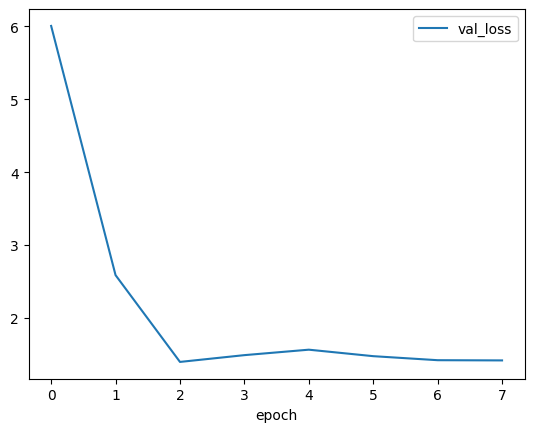

In [7]:
metrics = pandas.read_csv(os.path.join(trainer.log_dir, "metrics.csv"))
loss_metrics = metrics[["epoch", "val_loss"]].set_index("epoch")
plot = loss_metrics.plot()

It seems that after about 2 or 3 epochs the model found everything it could learn from the data. Because the early stopping mechanism was set to have 5 epochs of patience, it took the traning process to continue to epoch 7 before it was stopped.

# Test

Here we use the Trainer to run the model against the test data and collect the evaluation metrics. Given that this is a classification problem, we are interested in the metrics Acuracy, Precision and Recall.

In [8]:
scores = trainer.test(model, datamodule=datamodule, verbose=False)
accuracies = [round(scores[0]["test_accuracy_class_" + str(i)],2) for i in range(len(dataset.classes))]
precisions = [round(scores[0]["test_precision_class_" + str(i)],2) for i in range(len(dataset.classes))]
recalls = [round(scores[0]["test_recall_class_" + str(i)],2) for i in range(len(dataset.classes))]
df = pandas.DataFrame({"Class": dataset.classes, "Accuracy": accuracies, "Precision": precisions, "Recall": recalls}).set_index("Class")
df

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Bas\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 16.53it/s]


,Accuracy,Precision,Recall
Class,,,
chicken,0.60,0.75,0.60
cow,0.79,0.85,0.79
donkey,0.75,1.00,0.75
frog,0.86,0.50,0.86
sheep,0.55,0.67,0.55


In [9]:
test_dataloader = datamodule.test_dataloader()
files = [dataset.files[i] for i in test_dataloader.dataset.indices]
preds = trainer.predict(model, dataloaders=test_dataloader)
predictions = torch.cat(preds)
labels = torch.cat([y for x, y in test_dataloader])
results = []
for i, (file, truth, prediction) in enumerate(zip(files, labels, predictions)):
    probabilities = torch.softmax(prediction, dim=0)
    pred = torch.argmax(probabilities)
    confidence = round(float(probabilities[pred]),2)
    correct = "✅" if truth == pred else "❌"
    result = [file, dataset.classes[truth], dataset.classes[pred], confidence, correct]
    results.append(result)
df = pandas.DataFrame(results, columns=["File", "Truth", "Prediction", "Confidence", "Result"])
df

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Users\Bas\AppData\Local\Programs\Python\Python314\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 2/2 [00:00<00:00, 47.06it/s] 


,File,Truth,Prediction,Confidence,Result
0,data\donkey\esek_16.wav,donkey,donkey,0.61,✅
1,data\chicken\tavuk_8.wav,chicken,chicken,0.94,✅
2,data\chicken\tavuk_9.wav,chicken,frog,0.69,❌
3,data\cow\inek_55.wav,cow,cow,0.46,✅
4,data\sheep\koyun_20.wav,sheep,sheep,0.98,✅
5,data\sheep\koyun_18.wav,sheep,sheep,0.91,✅
6,data\cow\inek_72.wav,cow,cow,0.88,✅
7,data\sheep\koyun_24.wav,sheep,frog,0.67,❌
8,data\sheep\koyun_16.wav,sheep,frog,0.57,❌
9,data\sheep\koyun_27.wav,sheep,sheep,1.00,✅
